<a href="https://colab.research.google.com/github/Akanksha2622/olist-ecommerce-analysis/blob/main/olist_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
path = '/content/drive/My Drive/Olist Project/'

orders    = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
items     = pd.read_csv(path + 'olist_order_items_dataset.csv')
products  = pd.read_csv(path + 'olist_products_dataset.csv')
sellers   = pd.read_csv(path + 'olist_sellers_dataset.csv')
payments  = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
geo       = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category  = pd.read_csv(path + 'product_category_name_translation.csv')

print("Orders:",    orders.shape)
print("Customers:", customers.shape)
print("Items:",     items.shape)
print("Products:",  products.shape)
print("Sellers:",   sellers.shape)
print("Payments:",  payments.shape)
print("Reviews:",   reviews.shape)
print("Category:",  category.shape)

print("\n All 9 files loaded successfully!")

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Payments: (103886, 5)
Reviews: (99224, 7)
Category: (71, 2)

 All 9 files loaded successfully!


In [ ]:
# Step 1: merge orders with customers
df = orders.merge(customers, on='customer_id', how='left')

# Step 2: add items (what was bought and for how much)
df = df.merge(items, on='order_id', how='left')

# Step 3: add products (product category info)
df = df.merge(products, on='product_id', how='left')

# Step 4: add category names in English
df = df.merge(category, on='product_category_name', how='left')

# Step 5: add payments (how much was paid)
df = df.merge(payments, on='order_id', how='left')

# Step 6: add reviews (customer satisfaction)
df = df.merge(reviews, on='order_id', how='left')

print(f"Master table size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n All tables merged successfully!")
df.head()

Master table size: 119,143 rows × 37 columns

 All tables merged successfully!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [ ]:
# Convert date columns to proper datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Add useful time columns
df['order_year']  = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_day']   = df['order_purchase_timestamp'].dt.day_name()

# Calculate delivery time in days
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Calculate if delivery was late
df['is_late'] = (
    df['order_delivered_customer_date'] >
    df['order_estimated_delivery_date']
)

print(f"Delivery time — Average: {df['delivery_days'].mean():.1f} days")
print(f"Delivery time — Maximum: {df['delivery_days'].max():.0f} days")
print(f"Late deliveries: {df['is_late'].sum():,} orders")
print("\n Data cleaned and ready!")

Delivery time — Average: 12.0 days
Delivery time — Maximum: 209 days
Late deliveries: 9,068 orders

 Data cleaned and ready!


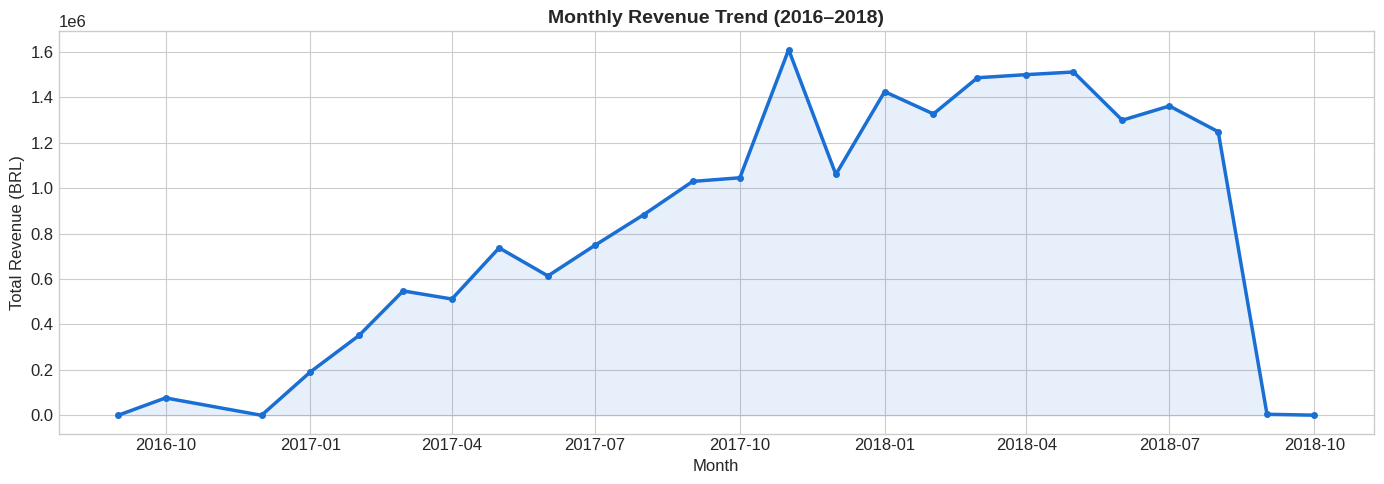

 Chart 1 done!


In [ ]:
# Calculate monthly revenue
monthly_revenue = df.groupby(['order_year', 'order_month'])['payment_value'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime(
    monthly_revenue['order_year'].astype(str) + '-' +
    monthly_revenue['order_month'].astype(str) + '-01'
)
monthly_revenue = monthly_revenue.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['date'], monthly_revenue['payment_value'],
         color='#1a6fd4', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(monthly_revenue['date'], monthly_revenue['payment_value'],
                 alpha=0.1, color='#1a6fd4')
plt.title('Monthly Revenue Trend (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart1_monthly_revenue.png', dpi=150)
plt.show()
print(" Chart 1 done!")

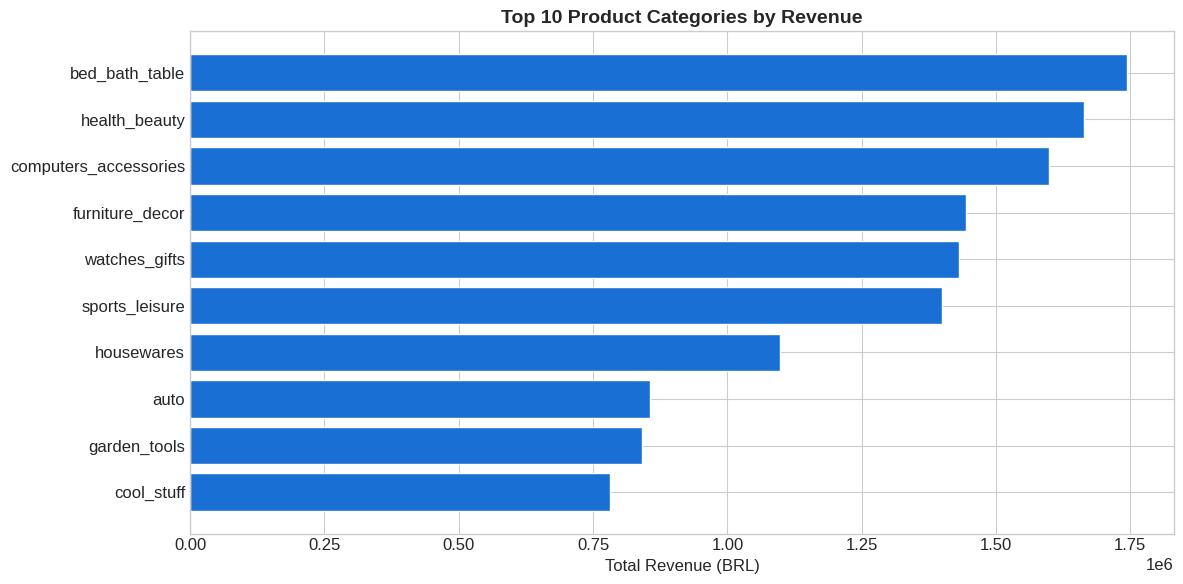

Chart 2 done!


In [ ]:
# Translate category names to English and find top 10
cat_revenue = df.groupby('product_category_name_english')['payment_value'].sum()
cat_revenue = cat_revenue.sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(cat_revenue.index, cat_revenue.values,
                color='#1a6fd4', edgecolor='white')
plt.title('Top 10 Product Categories by Revenue',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart2_top_categories.png', dpi=150)
plt.show()
print(f"Chart 2 done!")

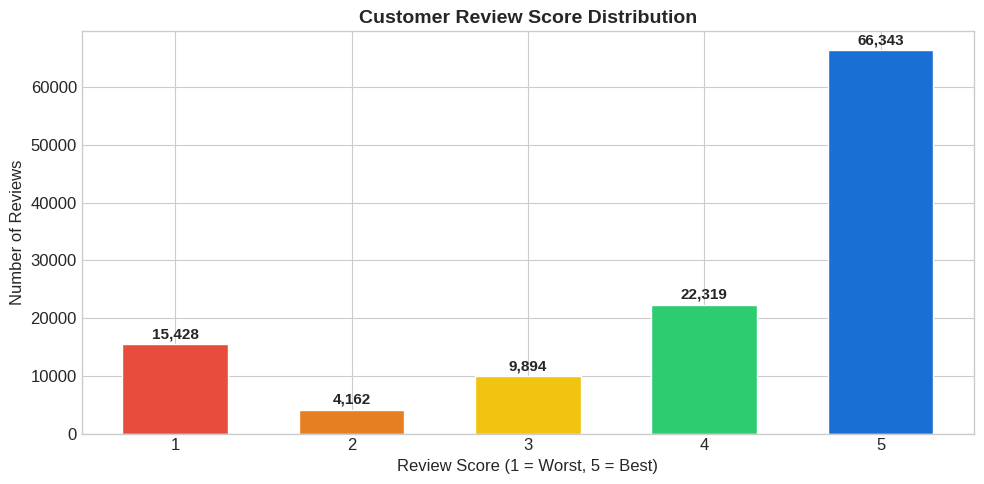

 Chart 3 done!


In [ ]:
review_counts = df['review_score'].value_counts().sort_index()

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1a6fd4']
plt.figure(figsize=(10, 5))
bars = plt.bar(review_counts.index, review_counts.values,
               color=colors, edgecolor='white', width=0.6)

# Add value labels on top of each bar
for bar, val in zip(bars, review_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Customer Review Score Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('Review Score (1 = Worst, 5 = Best)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart3_review_scores.png', dpi=150)
plt.show()
print(" Chart 3 done!")

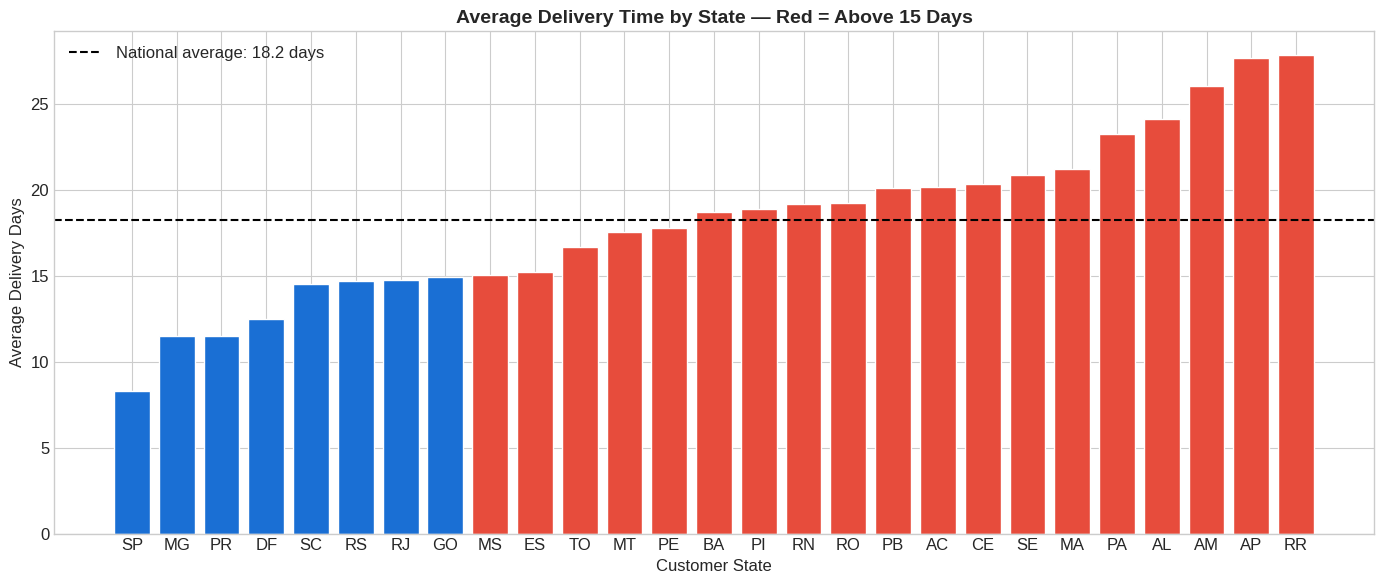

Chart 4 done!


In [ ]:
# Average delivery days by customer state
state_delivery = df.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=True)

plt.figure(figsize=(14, 6))
colors = ['#e74c3c' if x > 15 else '#1a6fd4' for x in state_delivery.values]
plt.bar(state_delivery.index, state_delivery.values,
        color=colors, edgecolor='white')
plt.title('Average Delivery Time by State — Red = Above 15 Days',
          fontsize=14, fontweight='bold')
plt.xlabel('Customer State')
plt.ylabel('Average Delivery Days')
plt.axhline(y=state_delivery.mean(), color='black',
            linestyle='--', label=f'National average: {state_delivery.mean():.1f} days')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart4_delivery_by_state.png', dpi=150)
plt.show()
print("Chart 4 done!")

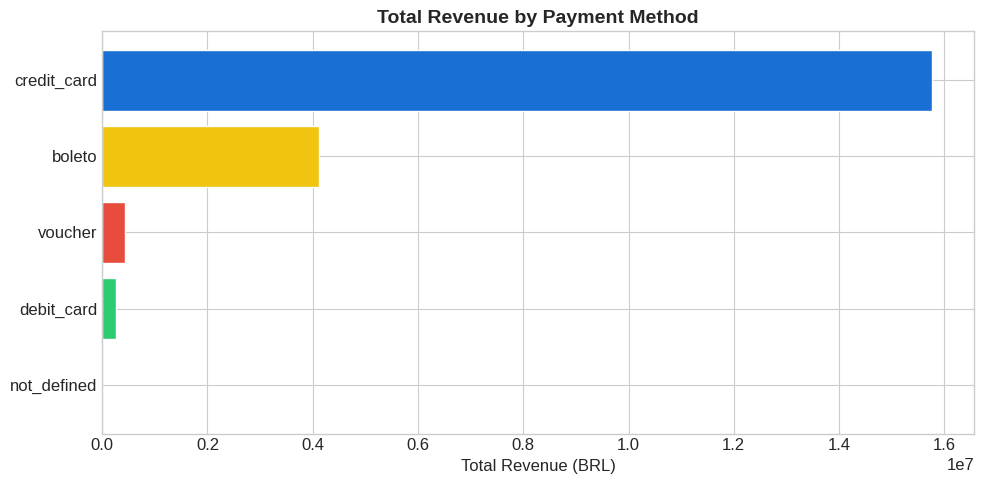

 Chart 5 done!


In [ ]:
payment_counts = df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#1a6fd4', '#2ecc71', '#e74c3c', '#f1c40f']
plt.barh(payment_counts.index, payment_counts.values,
         color=colors, edgecolor='white')
plt.title('Total Revenue by Payment Method',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart5_payment_methods.png', dpi=150)
plt.show()
print(" Chart 5 done!")

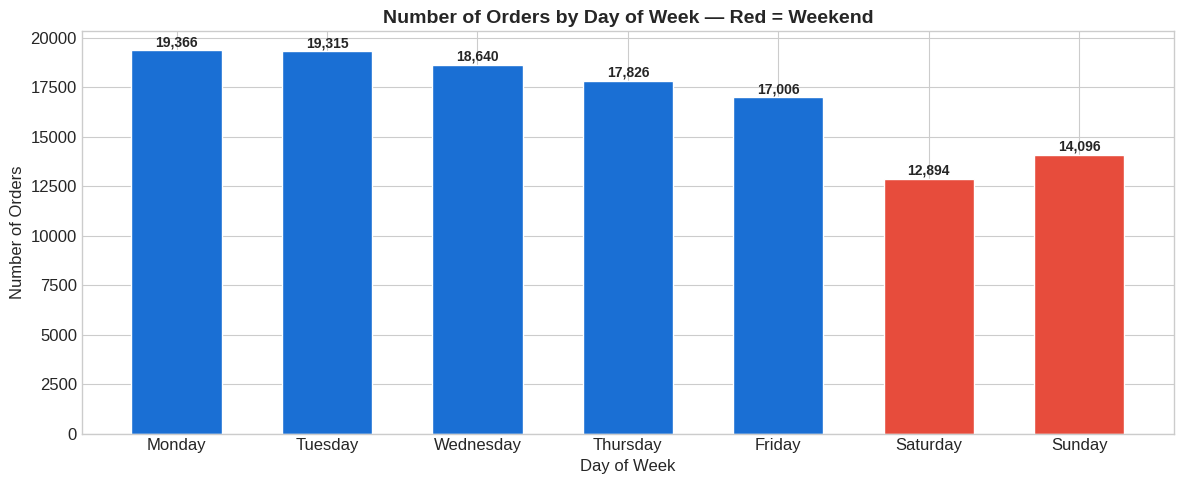

ALL 6 CHARTS DONE! 


In [ ]:
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df.groupby('order_dayofweek')['order_id'].count()
day_counts = day_counts.reindex(day_order)

colors = ['#e74c3c' if d in ['Saturday', 'Sunday']
          else '#1a6fd4' for d in day_order]

plt.figure(figsize=(12, 5))
plt.bar(day_counts.index, day_counts.values,
        color=colors, edgecolor='white', width=0.6)
plt.title('Number of Orders by Day of Week — Red = Weekend',
          fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
for i, val in enumerate(day_counts.values):
    plt.text(i, val + 200, f'{val:,}',
             ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Olist Project/chart6_orders_by_day.png', dpi=150)
plt.show()
print("ALL 6 CHARTS DONE! ")